# Readme

Code for all visualizations available under the "output" directory in repo.

# Imports & Load Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## print mult things
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [4]:
df = pd.read_csv("../data/raw_cases.csv")
df.head()

,case_name,case_type,court,date,case_href,full_text
0,北京丰冠体育有限公司等与中国滑雪协会等合同纠纷二审民事判决书,民事二审,北京市高级人民法院,2021-12-09,https://wenshu.court.gov.cn/website/wenshu/181...,NaN
1,刘慷、吉林省射击射箭运动管理中心人事争议民事再审民事裁定书,民事再审,吉林省高级人民法院,2021-11-05,https://wenshu.court.gov.cn/website/wenshu/181...,NaN
2,刘小宝、赵效男等买卖合同纠纷民事申请再审审查民事裁定书,民事再审,山东省高级人民法院,2021-07-05,https://wenshu.court.gov.cn/website/wenshu/181...,NaN
3,马晓三、云南省人民检察院劳动争议再审民事判决书,民事再审,云南省高级人民法院,2020-06-09,https://wenshu.court.gov.cn/website/wenshu/181...,NaN
4,李素萍与北京市木樨园体育运动技术学校劳动争议再审审查与审判监督民事裁定书,民事审判监督,北京市高级人民法院,2020-06-05,https://wenshu.court.gov.cn/website/wenshu/181...,NaN


# Pie Chart: Complaint categories

In [7]:
# prepare figure data.

# only keep first two characters to sort case type
# ['民事', '刑事', '行政', '执行']

df["case_type_categ"] = df["case_type"].astype(str).str[:2] 
print("all complaint types: ", df["case_type_categ"].unique())

all complaint types:  ['民事' '刑事' '行政' '执行']


In [8]:
categ_pie_df = df.groupby("case_type_categ")["case_name"].count()
categ_pie_df

case_type_categ
刑事     5
执行     3
民事    67
行政     6
Name: case_name, dtype: int64

In [9]:
# map to english translation

plot_df = categ_pie_df.reset_index()
plot_df.columns = ["case_type", "count"]

translate_map = {
    "民事" : "Civil",
    "刑事" : "Criminal",
    "行政" : "Administrative",
    "执行" : "Execution"
}

plot_df["case_type_EN"] = plot_df.case_type.map(translate_map)
plot_df

,case_type,count,case_type_EN
0,刑事,5,Criminal
1,执行,3,Execution
2,民事,67,Civil
3,行政,6,Administrative


([<matplotlib.patches.Wedge at 0x120059450>,
 [Text(1.0793808390252573, 0.21198350017190432, 'Criminal'),
  Text(0.9631140481491497, 0.5314238706134281, 'Execution'),
  Text(-1.0966922268957904, -0.08524177066645434, 'Civil'),
  Text(1.0703494541106127, -0.25367705076556196, 'Administrative')],
 [Text(0.5887531849228675, 0.1156273637301296, '6.2%\n(5)'),
  Text(0.5253349353540816, 0.2898675657891426, '3.7%\n(3)'),
  Text(-0.5981957601249765, -0.04649551127261146, '82.7%\n(67)'),
  Text(0.583826974969425, -0.13836930041757922, '7.4%\n(6)')])

Text(0.5, 0.98, 'Lawsuits by Type Relating to Retired Chinese Athletes')

Text(0.5, 1.0, 'Source: China Judgements Online')

Text(0.5, 0.05, 'Number of lawsuits found: 81 out of 164,680,709 cases')

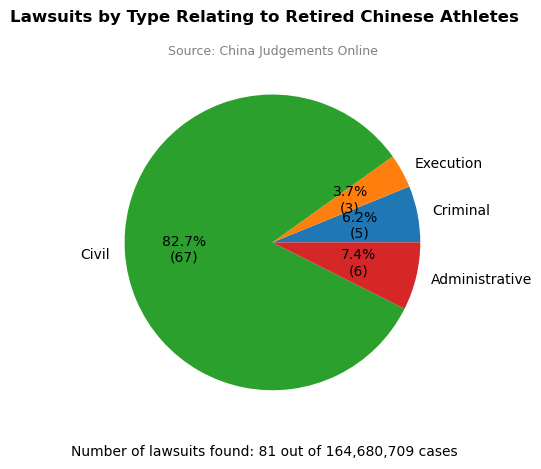

In [15]:
# draw (and save) figure

fig, ax = plt.subplots()
    # fig (Figure) — entire canvas/window
    # ax (Axes) — actual plot area inside the frame where data is drawn

ax.pie(
    plot_df["count"],
    labels = plot_df["case_type_EN"],
    autopct=lambda p: f"{p:.1f}%\n({int(round(p * plot_df['count'].sum() / 100))})",
)

fig.suptitle("Lawsuits by Type Relating to Retired Chinese Athletes", fontsize=12, fontweight="bold")
ax.set_title("Source: China Judgements Online", fontsize=9, color="gray", pad=2)

fig.text(0.5, 0.05, f"Number of lawsuits found: {plot_df['count'].sum()} out of 164,680,709 cases",
         ha="center", fontsize=10)


# fig.savefig("complaint_types.jpeg", format="jpeg", dpi=300, bbox_inches="tight")
plt.show()